In [1]:
import torch
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader




In [2]:
# here size of image isnt same for 0 -> 3,30,29 ; for 45-> 3,38,38
#so we need to generalise the image shape
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor()
])
transform=transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

In [3]:
train_dataset=datasets.GTSRB(
    root="data",
    split="train",
    download=True,
    transform=train_transform
)

test_dataset=datasets.GTSRB(
    root="data",
    split="test",
    download=True,
    transform=transform
)

len(train_dataset),len(test_dataset)

100%|██████████| 187M/187M [00:17<00:00, 10.8MB/s]
100%|██████████| 89.0M/89.0M [00:09<00:00, 9.85MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 184kB/s]


(26640, 12630)

In [4]:
image,label=train_dataset[0]

In [5]:
print(image.shape)
print(type(image))
print(type(label))
print(label)

torch.Size([3, 32, 32])
<class 'torch.Tensor'>
<class 'int'>
0


In [6]:
print(dir(train_dataset))


['__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_base_folder', '_check_exists', '_format_transform_repr', '_repr_indent', '_samples', '_split', '_target_folder', 'download', 'extra_repr', 'root', 'target_transform', 'transform', 'transforms']


Text(0.5, 1.0, 'Label: 0')

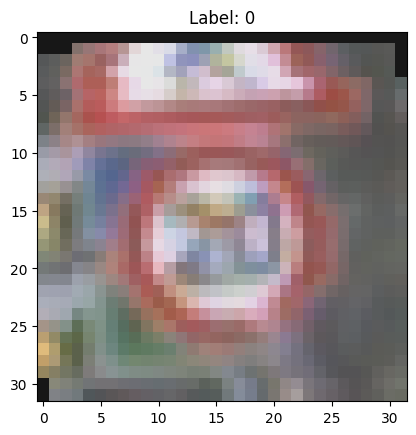

In [7]:
#matplotlib.pyplot.imshow expects images in the format (Height, Width, Channels) or (Height, Width) for grayscale, but the image tensor is in (Channels, Height, Width) format.
image,label=train_dataset[0]
plt.imshow(image.permute(1,2,0))
plt.title(f"Label: {label}")




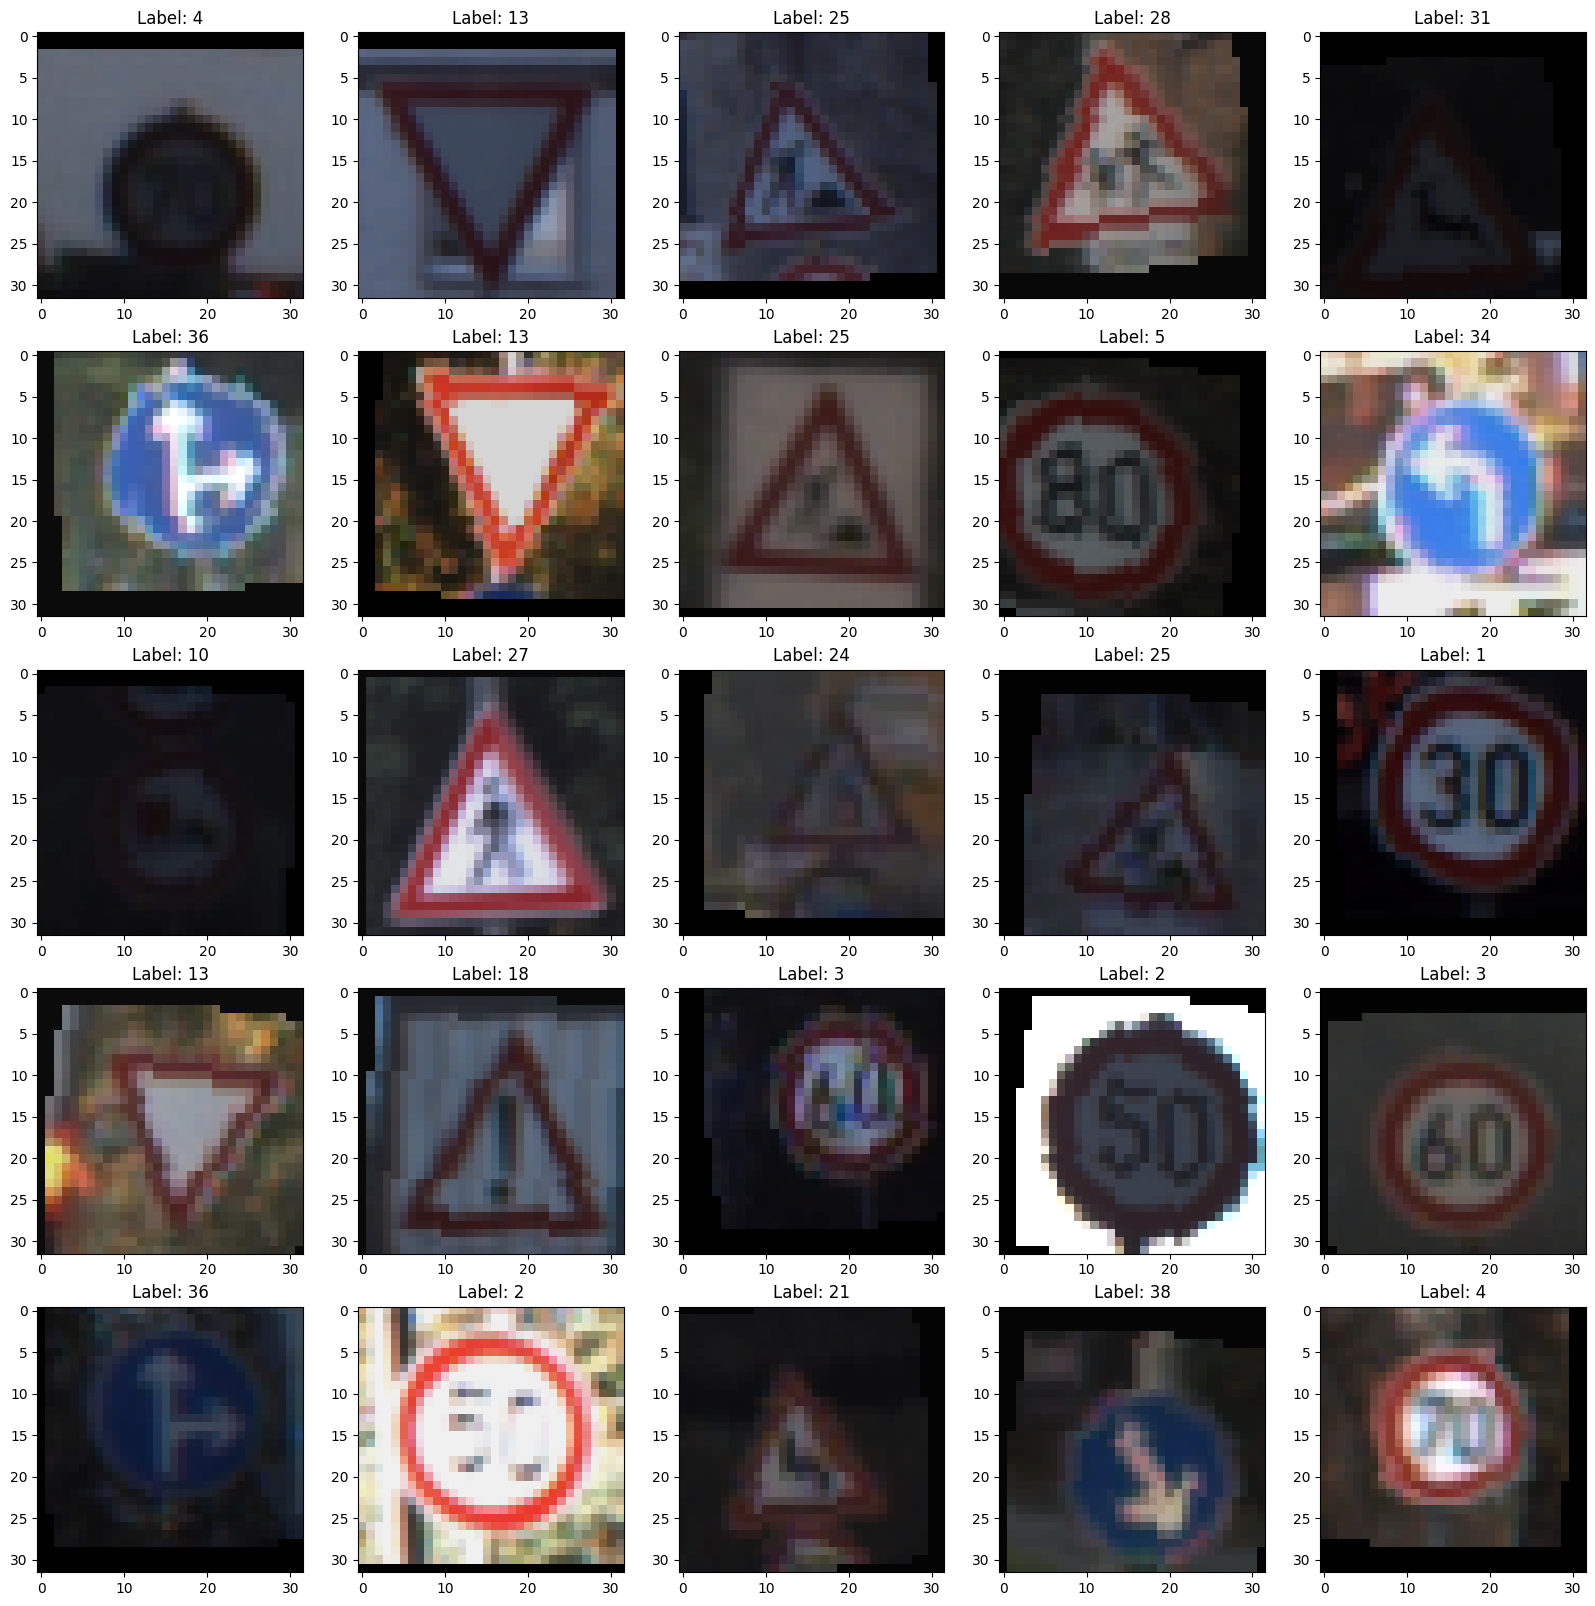

In [8]:
fig=plt.figure(figsize=(20,20))
rows,cols=5,5
for i in range(0,rows*cols):
    random_idx = torch.randint(0, len(train_dataset)-1,size=[1]).item()
    image,label=train_dataset[random_idx]
    fig.add_subplot(rows,cols,i+1)
    plt.imshow(image.permute(1,2,0))
    plt.title(f"Label: {label}")

In [9]:
train_dataset,test_dataset

(Dataset GTSRB
     Number of datapoints: 26640
     Root location: data
     StandardTransform
 Transform: Compose(
                Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
                RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
                RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))
                ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
                ToTensor()
            ),
 Dataset GTSRB
     Number of datapoints: 12630
     Root location: data
     StandardTransform
 Transform: Compose(
                Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [10]:
#Data loader
train_dataloader=DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)
test_dataloader=DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=True
)

In [11]:
print(f"DataLoader : {train_dataloader}\n Length of train Dataloader: {len(train_dataloader)}")
print(f"DataLoader : {test_dataloader}\n Length of test Dataloader: {len(test_dataloader)}")

DataLoader : <torch.utils.data.dataloader.DataLoader object at 0x79dd50ce6540>
 Length of train Dataloader: 833
DataLoader : <torch.utils.data.dataloader.DataLoader object at 0x79dd513b6060>
 Length of test Dataloader: 395


In [12]:
labels = [label for _, label in train_dataset]
print(len(set(labels)))

43


In [13]:
#Build Model

class GTSRBModel(nn.Module):
  def __init__(self,input_size:int,hidden_units:int,output_size:int):
     super().__init__()
     self.conv_block_1=nn.Sequential(
         nn.Conv2d(
             in_channels=input_size,
             out_channels=hidden_units,
             kernel_size=3,
             stride=1,
             padding=1
         ),
         nn.ReLU(),
         nn.MaxPool2d(kernel_size=2)
     )
     self.conv_block_2=nn.Sequential(
         nn.Conv2d(
             in_channels=hidden_units,
             out_channels=hidden_units*2,
             stride=1,
             kernel_size=3,
             padding=1
         ),
         nn.ReLU(),
         nn.MaxPool2d(kernel_size=2)
     )
     self.classifier=nn.Sequential(
         nn.Flatten(),
         nn.Linear(
             in_features=hidden_units*2*8*8,
             out_features=output_size
         )
     )
  def forward(self,x):
    x=self.conv_block_1(x)
    x=self.conv_block_2(x)
    x=self.classifier(x)
    return x



In [14]:
model_0=GTSRBModel(
    input_size=3,
    hidden_units=32,
    output_size=43
)
model_0

GTSRBModel(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=43, bias=True)
  )
)

In [15]:
#loss and optimiser
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(
    params=model_0.parameters(),
    lr=0.001
)
print(f"Loss function: {loss_fn}")
print(f"Optimizer: {optimizer}")

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [16]:
from tqdm.auto import tqdm

epochs=10
train_losses=[]
test_losses=[]
test_accs=[]
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_0.to(device)
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---")

  train_loss=0
  #Training
  model_0.train()
  #forward propagation in batches
  for X,y in train_dataloader:
    X,y=X.to(device),y.to(device)
    y_pred=model_0(X)
    #loss
    loss=loss_fn(y_pred,y)
    train_loss+=loss
    #optimizer zero grad
    optimizer.zero_grad()
    #backward propagation
    loss.backward()
    #optimizer tsep
    optimizer.step()
  train_loss/=len(train_dataloader)

  #Testing
  test_loss,test_acc=0,0
  model_0.eval()
  with torch.inference_mode():
    for X_test,y_test in test_dataloader:
      X_test,y_test=X_test.to(device),y_test.to(device)
      test_pred=model_0(X_test)
      test_loss += loss_fn(test_pred, y_test)
      test_acc += (test_pred.argmax(dim=1) == y_test).sum().item()
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataset)

  #save losses

  train_losses.append(train_loss.item())
  test_losses.append(test_loss.item())
  test_accs.append(test_acc)

  print(f"Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc*100:.2f}%")





  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
---
Train loss: 2.0221 | Test loss: 1.2883 | Test acc: 62.76%
Epoch: 1
---
Train loss: 0.8672 | Test loss: 0.8462 | Test acc: 75.71%
Epoch: 2
---
Train loss: 0.5527 | Test loss: 0.7234 | Test acc: 79.39%
Epoch: 3
---
Train loss: 0.4063 | Test loss: 0.6051 | Test acc: 83.37%
Epoch: 4
---
Train loss: 0.3099 | Test loss: 0.5865 | Test acc: 84.36%
Epoch: 5
---
Train loss: 0.2578 | Test loss: 0.5822 | Test acc: 84.59%
Epoch: 6
---
Train loss: 0.2169 | Test loss: 0.5090 | Test acc: 86.37%
Epoch: 7
---
Train loss: 0.1890 | Test loss: 0.5295 | Test acc: 86.18%
Epoch: 8
---
Train loss: 0.1748 | Test loss: 0.4500 | Test acc: 87.80%
Epoch: 9
---
Train loss: 0.1559 | Test loss: 0.4744 | Test acc: 88.26%


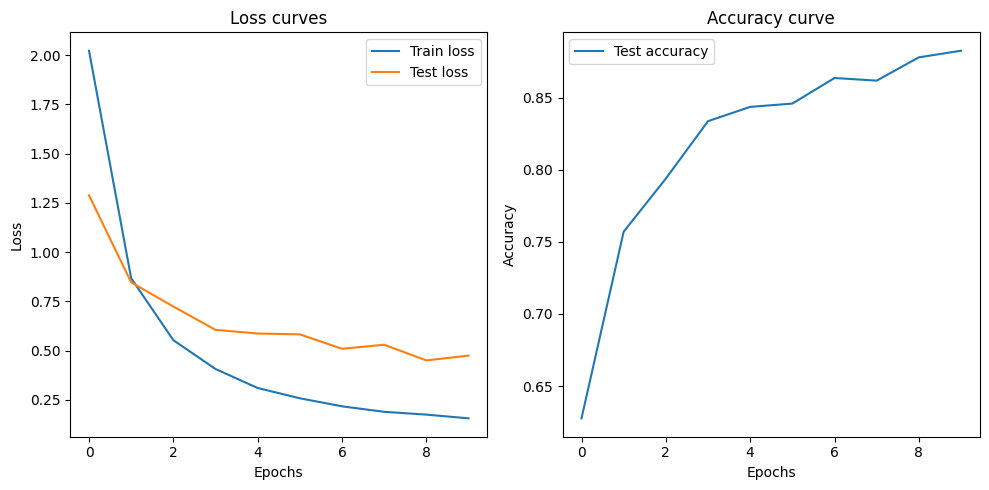

In [17]:
import matplotlib.pyplot as plt

epochs_range = range(len(train_losses))

plt.figure(figsize=(10, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train loss')
plt.plot(epochs_range, test_losses, label='Test loss')
plt.title('Loss curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, test_accs, label='Test accuracy')
plt.title('Accuracy curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

#MODEL RESNET18

In [18]:
from torchvision.models import resnet18,ResNet18_Weights

In [19]:
train_transform_resnet = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

test_transform_resnet = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [20]:
train_dataset_resnet = datasets.GTSRB(
    root="data",
    split="train",
    download=True,
    transform=train_transform_resnet
)

test_dataset_resnet = datasets.GTSRB(
    root="data",
    split="test",
    download=True,
    transform=test_transform_resnet
)

In [21]:
train_dataloader_resnet = DataLoader(
    train_dataset_resnet,
    batch_size=32,
    shuffle=True
)

test_dataloader_resnet = DataLoader(
    test_dataset_resnet,
    batch_size=32,
    shuffle=False
)

In [22]:
weights = ResNet18_Weights.DEFAULT

model_resnet = resnet18(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


In [23]:
print(model_resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
print(model_resnet.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [25]:
model_resnet.fc = nn.Linear(
    in_features=model_resnet.fc.in_features,
    out_features=43
)

In [26]:
model_resnet.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [27]:
loss_fn_resnet = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(model_resnet.parameters(),lr=0.0001)

In [28]:
from tqdm.auto import tqdm

epochs=3
train_losses_resnet=[]
test_losses_resnet=[]
test_accs_resnet=[]
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_resnet.to(device)
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---")

  train_loss=0
  #Training
  model_resnet.train()
  #forward propagation in batches
  for X,y in train_dataloader_resnet:
    X,y=X.to(device),y.to(device)
    y_pred=model_resnet(X)
    #loss
    loss=loss_fn_resnet(y_pred,y)
    train_loss+=loss.item()
    #optimizer zero grad
    optimizer_resnet.zero_grad()
    #backward propagation
    loss.backward()
    #optimizer tsep
    optimizer_resnet.step()
  train_loss/=len(train_dataloader_resnet)

  #Testing
  test_loss,test_acc=0,0
  model_resnet.eval()
  with torch.inference_mode():
    for X_test,y_test in test_dataloader_resnet:
      X_test,y_test=X_test.to(device),y_test.to(device)
      test_pred=model_resnet(X_test)
      test_loss += loss_fn_resnet(test_pred, y_test).item()
      test_acc += (test_pred.argmax(dim=1) == y_test).sum().item()
    test_loss /= len(test_dataloader_resnet)
    test_acc /= len(test_dataset_resnet)

  #save losses

  train_losses_resnet.append(train_loss)
  test_losses_resnet.append(test_loss)
  test_accs_resnet.append(test_acc)

  print(f"Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc*100:.2f}%")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---
Train loss: 0.2545 | Test loss: 0.0735 | Test acc: 98.08%
Epoch: 1
---
Train loss: 0.0114 | Test loss: 0.0581 | Test acc: 98.29%
Epoch: 2
---
Train loss: 0.0069 | Test loss: 0.0440 | Test acc: 98.61%


In [29]:
torch.save(model_resnet.state_dict(), "resnet18_gtsrb.pth")

print("Model Saved Successfully!")

Model Saved Successfully!


In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model_resnet.eval()

y_true = []
y_pred = []

with torch.inference_mode():
    for X, y in test_dataloader_resnet:
        X = X.to(device)
        y = y.to(device)

        outputs = model_resnet(X)

        preds = outputs.argmax(dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [31]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.99      1.00      1.00       720
           2       0.99      1.00      0.99       750
           3       0.99      0.97      0.98       450
           4       1.00      0.99      1.00       660
           5       0.98      0.99      0.98       630
           6       0.96      0.99      0.98       150
           7       1.00      1.00      1.00       450
           8       0.99      0.98      0.98       450
           9       0.98      1.00      0.99       480
          10       1.00      1.00      1.00       660
          11       0.95      0.98      0.96       420
          12       1.00      0.98      0.99       690
          13       0.98      1.00      0.99       720
          14       1.00      1.00      1.00       270
          15       1.00      1.00      1.00       210
          16       1.00      1.00      1.00       150
          17       1.00    

<Figure size 4000x4000 with 0 Axes>

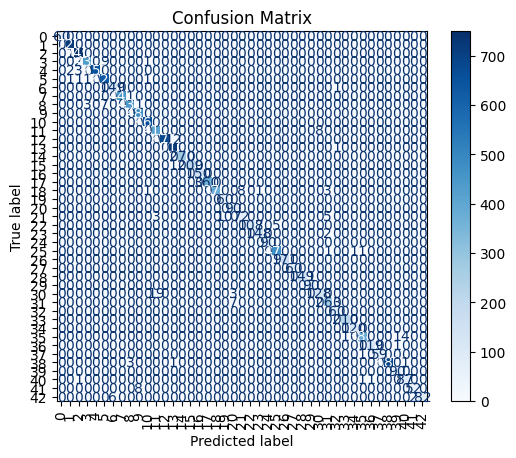

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(40,40))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=90)

plt.title("Confusion Matrix")
plt.show()

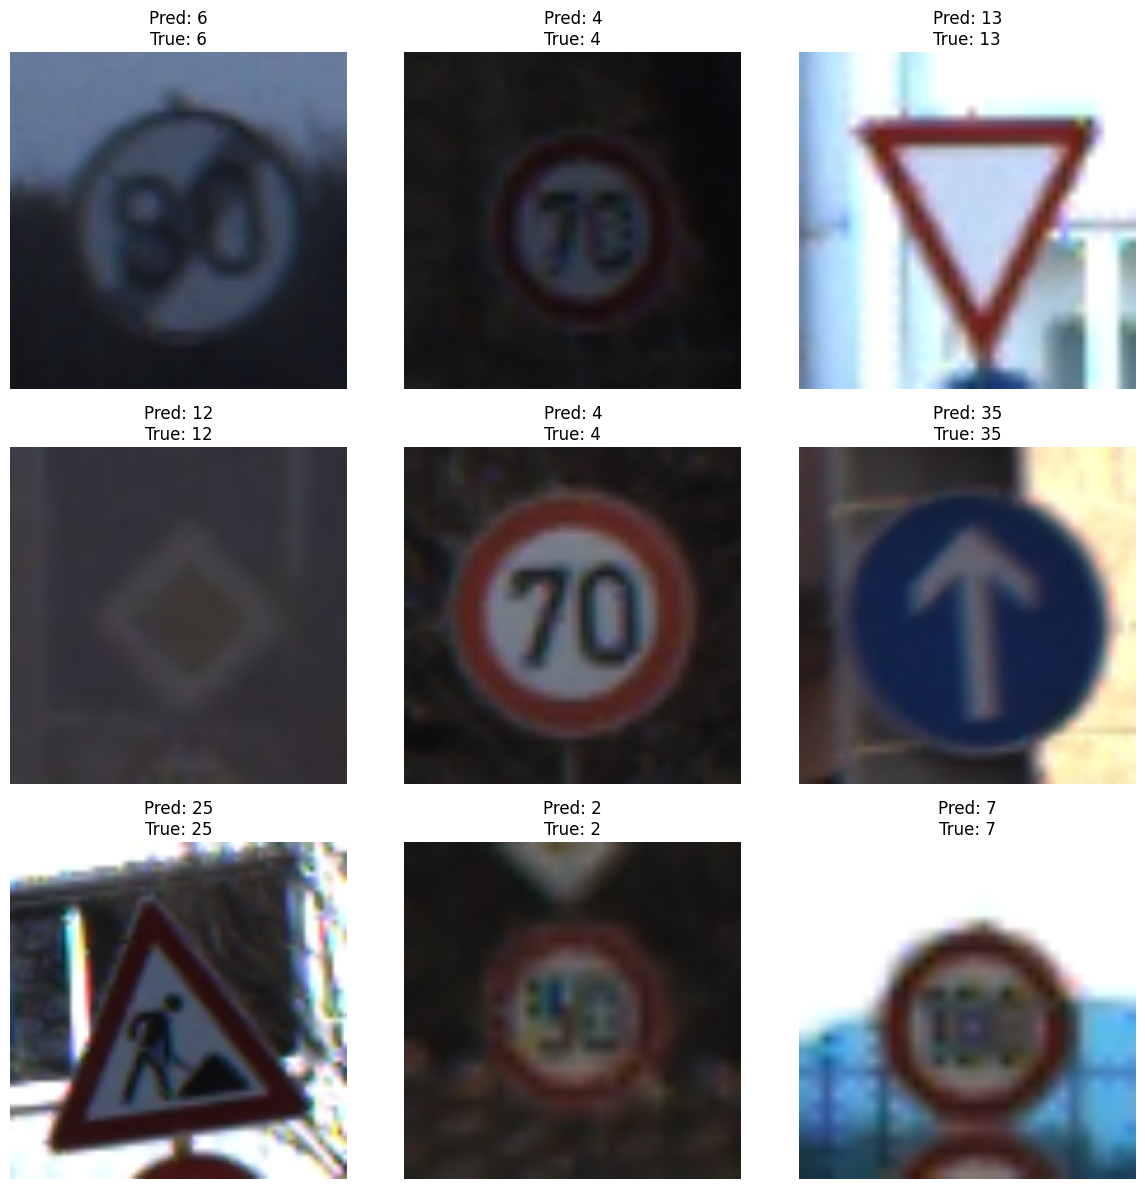

In [33]:
import random

fig, axes = plt.subplots(3,3, figsize=(12,12))

model_resnet.eval()

for ax in axes.flat:

    idx = random.randint(0, len(test_dataset_resnet)-1)

    image, label = test_dataset_resnet[idx]

    with torch.inference_mode():

        pred = model_resnet(
            image.unsqueeze(0).to(device)
        ).argmax(dim=1).item()

    ax.imshow(image.permute(1,2,0))
    ax.set_title(f"Pred: {pred}\nTrue: {label}")

    ax.axis("off")

plt.tight_layout()
plt.show()

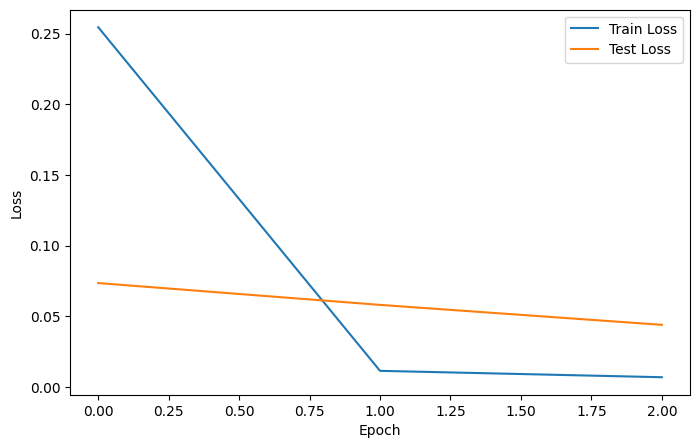

In [34]:
plt.figure(figsize=(8,5))

plt.plot(train_losses_resnet,label="Train Loss")
plt.plot(test_losses_resnet,label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("loss_curve_resnet.png")

plt.show()

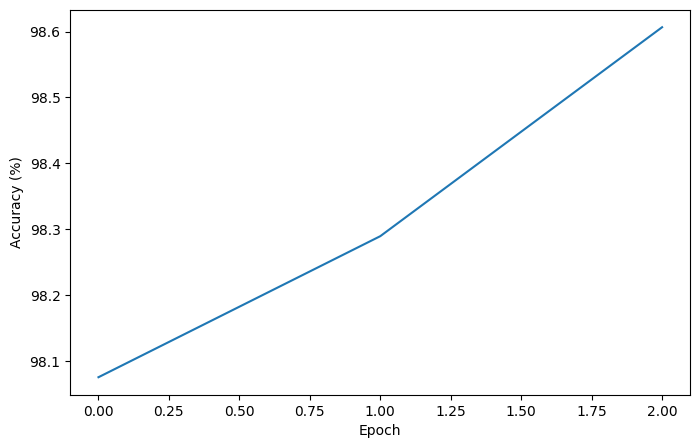

In [35]:
plt.figure(figsize=(8,5))

plt.plot([x*100 for x in test_accs_resnet])

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.savefig("accuracy_curve_resnet.png")

plt.show()

In [36]:
from google.colab import files
files.download("resnet18_gtsrb.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
from google.colab import files

#
files.download("accuracy_curve_resnet.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
%%writefile requirements.txt
torch
torchvision
numpy
matplotlib
scikit-learn
tqdm

Writing requirements.txt


In [39]:
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
from google.colab import files

#
files.download("loss_curve_resnet.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>